In [1]:
from pathlib import Path
import yaml
import numpy as np
from astropy import stats
from astropy.time import Time
from astropy.table import Table, MaskedColumn
from kpf_etc.etc import kpf_photon_noise_estimate

import matplotlib.pyplot as plt

data_file = 'data/Feb2026_withInstZPs.csv'
t = Table.read(data_file, format='ascii.csv')

In [2]:
wavs = ['452', '548', '652', '747', '852']
EMbins = [1, 2, 3, 4]

# Find the "Best" Exposure Meter Bin for Each Science Wavelength

Look at the spread in zero point differences and find the Exposure Meter Bin with the least scatter in zero poitn differences and use that at the "best" exposure meter bin to use for the science wavelength under test.

In [3]:
def find_best_ExpMeterBin(t, wav, plot=True):
    EMwav = {1: ' 498nm',
             2: ' 604nm',
             3: ' 710nm',
             4: ' 817nm',
             }

    if plot: plt.figure(figsize=(12,2))
    comparison_stddev = []
    comparison_median = []
    for EMbin in EMbins:
        ZPdiff = t[f'ZP_{wav}'] - t[f'EMZP_{EMbin}']
        mask = t[f'ZP_{wav}'].mask | t[f'EMZP_{EMbin}'].mask
        mean, median, stddev = stats.sigma_clipped_stats(ZPdiff[~mask])
        comparison_stddev.append(float(stddev))
        comparison_median.append(float(median))
    
        plt.subplot(1,4,EMbin)
        plt.title(f'{wav}nm-{EMbin}: {median:.2f}+/-{stddev:.3f}')
        bins = np.arange(median-10*stddev, median+10*stddev, 0.01)
        plt.hist(ZPdiff[~mask], bins=bins, color='b', alpha=0.4,
                 density=True, log=False)
        
        if EMbin == 1: plt.ylabel(f'Density (N={len(ZPdiff)})')
        plt.gca().set_xticks([])
        plt.xlabel(f'')
    
    plt.show()
    best_EMbin = EMbins[np.argmin(comparison_stddev)]
    return best_EMbin, EMwav[best_EMbin].strip()

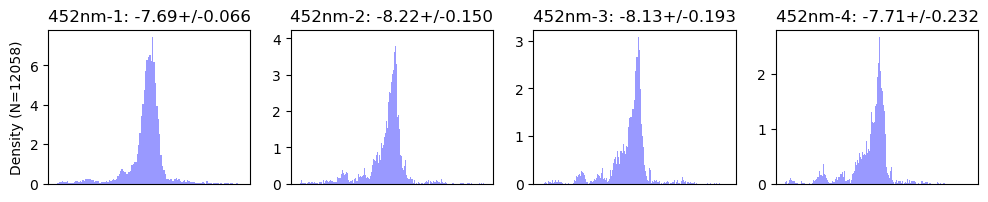

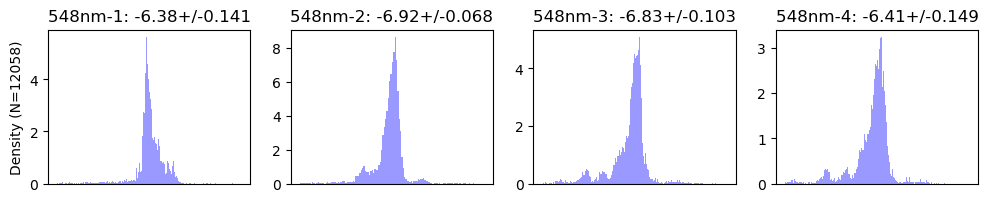

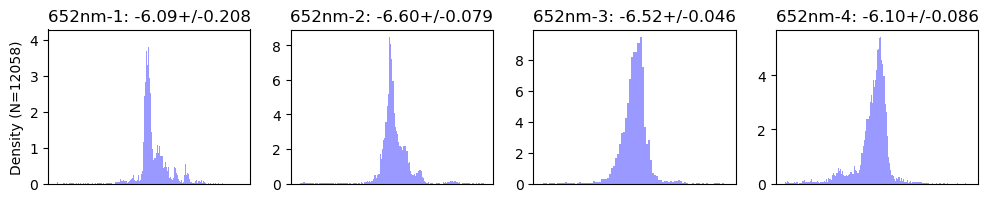

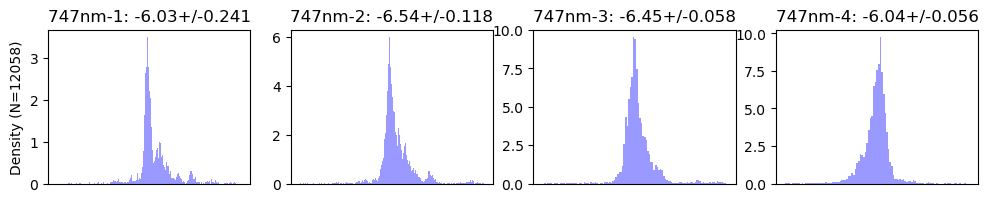

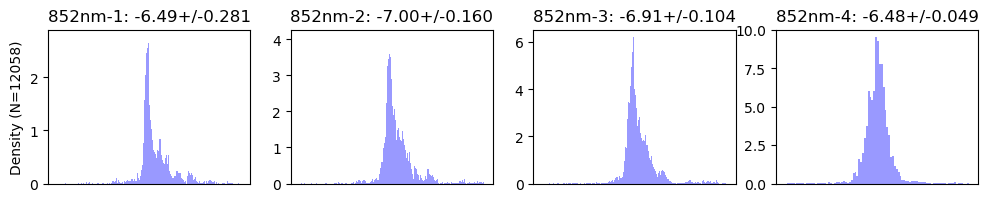

In [4]:
best_EMbin = {}
for wav in wavs:
    EMbin, EMwav = find_best_ExpMeterBin(t, wav, plot=True)
    best_EMbin[wav] = EMbin

In [5]:
best_EMbin

{'452': 1, '548': 2, '652': 3, '747': 4, '852': 4}

# Save Results to Disk

In [6]:
EMbinfile = Path('data/ExpMeterBins.yaml')
if EMbinfile.exists(): EMbinfile.unlink()
with open(EMbinfile, 'w') as f:
    f.write(yaml.dump(best_EMbin))

# Look at Conversion Factors

This is doing the same examination as above, but in linear space instead of log space (magnitudes).  We're doing this purely as a verification step to make sure we get the same result.

In [7]:
for wav in wavs:
    for EMbin in EMbins:
        t.add_column(MaskedColumn(t[f'TOTCORR_{EMbin}']/t[f'SNRSC{wav}']**2), name=f'CV_{wav}_{EMbin}')
        t[f'CV_{wav}_{EMbin}'].mask = t[f'TOTCORR_{EMbin}'].mask | t[f'SNRSC{wav}'].mask | (t[f'TOTCORR_{EMbin}'] <= 0) | (t[f'SNRSC{wav}'] <= 0)


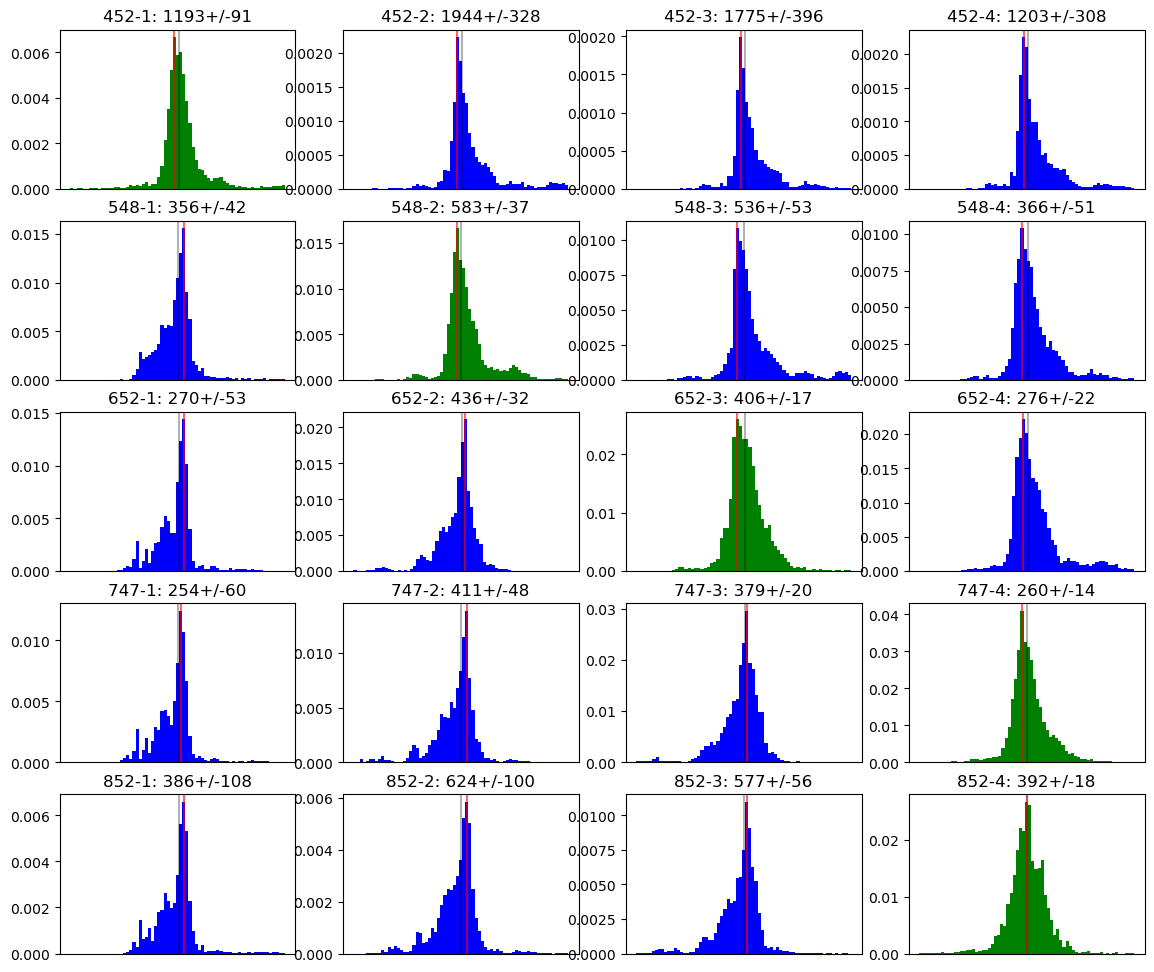

In [8]:
conversion = {}

plt.figure(figsize=(14,12))
for i,wav in enumerate(wavs):
    for EMbin in EMbins:
        best = best_EMbin[wav] == EMbin
        hcolor = {True: 'g', False: 'b'}[best]
        plt.subplot(5,4,i*4+EMbin)
        conversions = t[f'CV_{wav}_{EMbin}'][~t[f'CV_{wav}_{EMbin}'].mask]
        Nc = len(conversions)
        mean, median, stdev = stats.sigma_clipped_stats(conversions)
        bins = np.arange(median-7*stdev, median+7*stdev, np.ceil(stdev)/5)
        n, b, _ = plt.hist(conversions, bins=bins, color=hcolor, density=True)
        wmode = np.argmax(n)
        mode = (b[wmode]+b[wmode+1])/2
        if best:
            conversion[f"{wav}"] = float(median)
        title = f"{wav}-{EMbin}: {median:.0f}+/-{stdev:.0f}"
        plt.title(title)
        plt.axvline(median, color='k', alpha=0.3, label='median')
        plt.axvline(mode, color='r', alpha=0.6, label='mode')
        # plt.legend(loc='best')
        plt.gca().set_xticks([])
plt.show()

### Discussion

From this we get the conversion rate between Exposure Meter ADU and spectrograph detected photons which we can compare against the previously calculated zero point difference and see that they are consistent.

In [9]:
for wav in wavs:
    print(f"{wav}nm: {conversion[wav]:4.0f} EMADU/photon = {-2.5*np.log10(conversion[wav]):.2f} mag zero point difference")

452nm: 1193 EMADU/photon = -7.69 mag zero point difference
548nm:  583 EMADU/photon = -6.91 mag zero point difference
652nm:  406 EMADU/photon = -6.52 mag zero point difference
747nm:  260 EMADU/photon = -6.04 mag zero point difference
852nm:  392 EMADU/photon = -6.48 mag zero point difference
